# Agent 2 — Approval / Escalation Classifier

Logistic Regression approval classifier, converted from `agent2_approval_classifier.py`.

**What this notebook fixes vs. the original `train_models.py`:**

1. **Near-deterministic label.** The old generator set `approved` from a hard `if` on `cp_risk`, `amount>limit`, `is_anomaly` with only 20% noise — and those same quantities were fed back as features. The model recovered the generator rule, not a pattern.
2. **No evaluation.** `.fit()` on all rows, then pickled.
3. **Unscaled features for Logistic Regression.** `amount_ratio` (0–50) and `cp_risk` (0–2) on wildly different scales.
4. **Broken `days_since_last_txn`** — computed as the gap between globally-sorted, unrelated rows. It should be per-counterparty.
5. **Lossy encoding** — `pd.factorize(user_role)` invented an ordinal ranking over unordered roles.

This notebook uses the realistic `_v2` data, a proper `Pipeline` (scaling + one-hot), a per-counterparty gap feature, 5-fold CV ROC-AUC, a confusion matrix, and coefficient explainability.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
HERE = os.getcwd()
DATA_DIR = os.path.join(HERE, '..', 'data')
MODELS_DIR = os.path.join(HERE, '..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

DATA_FILE = os.path.join(DATA_DIR, 'historical_transactions_v2.csv')
if not os.path.exists(DATA_FILE):
    DATA_FILE = os.path.join(DATA_DIR, 'historical_transactions.csv')

NUMERIC = ['amount_ratio', 'log_amount', 'days_since_last_txn']
CATEGORICAL = ['transaction_type', 'counterparty_risk', 'user_role']
print('data file:', os.path.basename(DATA_FILE))

data file: historical_transactions_v2.csv


## Feature engineering

`days_since_last_txn` is computed per counterparty — the real signal.

In [3]:
def build_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['amount_ratio'] = df['amount'] / df['daily_limit']
    df['log_amount'] = np.log1p(df['amount'])

    # FIX: gap since the PREVIOUS transaction of the SAME counterparty.
    df = df.sort_values(['counterparty_name', 'date'])
    df['days_since_last_txn'] = (
        df.groupby('counterparty_name')['date'].diff().dt.days
    ).fillna(0.0)
    return df

In [4]:
df = build_features(pd.read_csv(DATA_FILE))
X = df[NUMERIC + CATEGORICAL]
y = df['approved'].astype(int)
print(f'rows={len(df)}  approved rate={y.mean():.3f}')
X.head()

rows=1000  approved rate=0.452


,amount_ratio,log_amount,days_since_last_txn,transaction_type,counterparty_risk,user_role
688,0.134984,9.510400,0.0,ach_transfer,low,treasury_manager
178,0.114394,9.344902,5.0,wire_payment,low,treasury_analyst
430,0.263310,10.178538,3.0,internal_transfer,low,cfo
674,0.078981,8.974502,0.0,internal_transfer,low,treasury_analyst
443,0.111387,9.318268,1.0,fee,low,cfo


## Pipeline: scale numeric + one-hot categorical + Logistic Regression

In [5]:
pre = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
])
pipe = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=1000, random_state=42,
                               class_weight='balanced')),
])

## Cross-validated ROC-AUC — does it generalise?

In [6]:
cv_auc = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC-AUC : {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}')
if cv_auc.mean() > 0.99:
    print('  >> WARNING: AUC ~1.0 -- label is a deterministic function of')
    print('     the features (data leakage). Regenerate with generate_data.py.')
else:
    print('  >> OK: realistic AUC -- the model learned a genuine pattern.')

5-fold CV ROC-AUC : 0.803 +/- 0.073
  >> OK: realistic AUC -- the model learned a genuine pattern.


## Held-out test split

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
pred = pipe.predict(X_te)

print('--- Held-out test performance ---')
print(f'ROC-AUC : {roc_auc_score(y_te, proba):.3f}')
print('Confusion matrix [[TN FP] [FN TP]]:')
print(confusion_matrix(y_te, pred))
print(classification_report(y_te, pred, digits=3,
                            target_names=['escalate(0)', 'approve(1)']))

--- Held-out test performance ---
ROC-AUC : 0.848
Confusion matrix [[TN FP] [FN TP]]:
[[109  28]
 [ 22  91]]
              precision    recall  f1-score   support

 escalate(0)      0.832     0.796     0.813       137
  approve(1)      0.765     0.805     0.784       113

    accuracy                          0.800       250
   macro avg      0.798     0.800     0.799       250
weighted avg      0.802     0.800     0.800       250



In [8]:
# Explainability: which features drive approval?
feat_names = (NUMERIC +
              list(pipe.named_steps['pre']
                   .named_transformers_['cat']
                   .get_feature_names_out(CATEGORICAL)))
coefs = pipe.named_steps['clf'].coef_[0]
print('--- Logistic regression coefficients (sorted by impact) ---')
for name, c in sorted(zip(feat_names, coefs), key=lambda t: -abs(t[1])):
    direction = '-> approve' if c > 0 else '-> escalate'
    print(f'  {name:28s} {c:+.3f}  {direction}')

--- Logistic regression coefficients (sorted by impact) ---
  amount_ratio                 -1.338  -> escalate
  counterparty_risk_high       -1.010  -> escalate
  counterparty_risk_low        +0.648  -> approve
  log_amount                   -0.561  -> escalate
  counterparty_risk_medium     +0.334  -> approve
  transaction_type_wire_payment +0.257  -> approve
  transaction_type_ach_transfer -0.254  -> escalate
  user_role_treasury_manager   -0.194  -> escalate
  user_role_cfo                +0.191  -> approve
  days_since_last_txn          +0.075  -> approve
  transaction_type_internal_transfer -0.038  -> escalate
  user_role_treasury_analyst   -0.025  -> escalate
  transaction_type_fee         +0.006  -> approve


## Plots — confusion matrix, ROC, coefficient impact

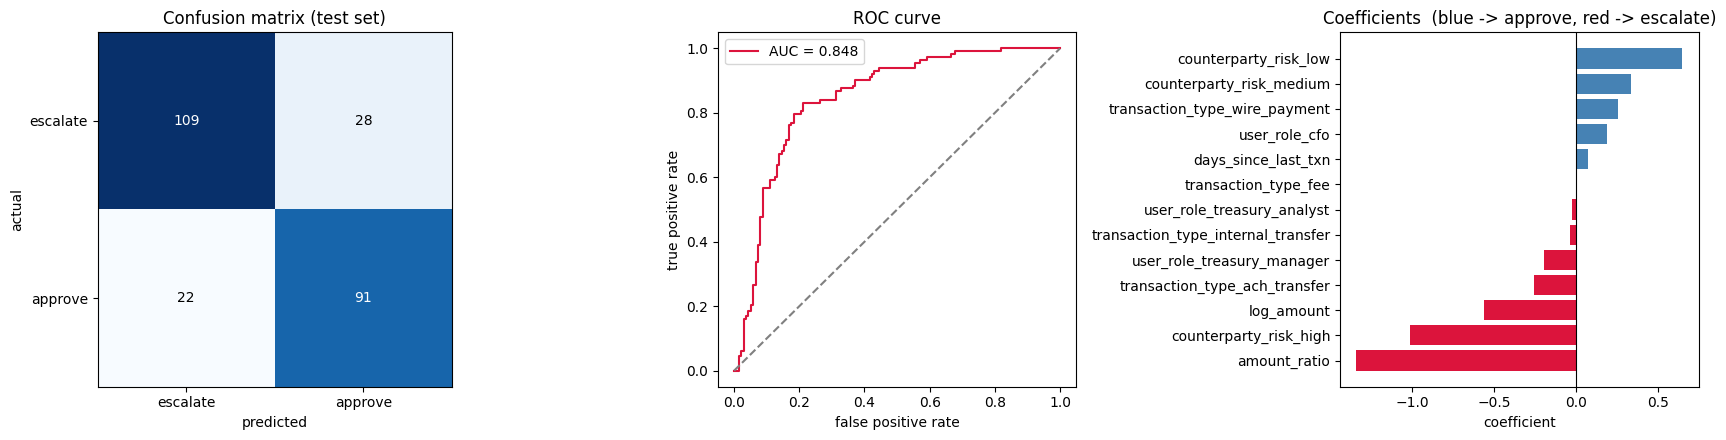

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1. confusion matrix heatmap
cm = confusion_matrix(y_te, pred)
ax = axes[0]
ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center',
            color='white' if v > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['escalate', 'approve'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['escalate', 'approve'])
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix (test set)')

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_te, proba)
ax = axes[1]
ax.plot(fpr, tpr, color='crimson',
        label=f'AUC = {roc_auc_score(y_te, proba):.3f}')
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_title('ROC curve'); ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate'); ax.legend()

# 3. coefficient impact
ax = axes[2]
order_ = np.argsort(coefs)
bar_colors = ['crimson' if coefs[i] < 0 else 'steelblue' for i in order_]
ax.barh([feat_names[i] for i in order_], coefs[order_], color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Coefficients  (blue -> approve, red -> escalate)')
ax.set_xlabel('coefficient')

plt.tight_layout(); plt.show()

## Retrain on all data and serialise

The pickle is a **dict**: fitted `Pipeline` + feature lists + CV score.

In [10]:
pipe.fit(X, y)
bundle = {
    'model': pipe,
    'numeric_features': NUMERIC,
    'categorical_features': CATEGORICAL,
    'cv_roc_auc': float(cv_auc.mean()),
}
out = os.path.join(MODELS_DIR, 'approval_classifier.pkl')
with open(out, 'wb') as f:
    pickle.dump(bundle, f)
print(f'Saved {out}')
print('  (pickle is a dict: fitted Pipeline + feature lists + CV score)')

Saved C:\CATAS\CATAS\ml\..\models\approval_classifier.pkl
  (pickle is a dict: fitted Pipeline + feature lists + CV score)
